In [236]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [237]:
carr = pd.read_csv('carr.csv')
carr["ticker"] = "CARR"
ea = pd.read_csv("ea.csv")
ea["ticker"] = "EA"
ms = pd.read_csv("ms.csv")
ms["ticker"] = "MS"
spg = pd.read_csv("spg.csv")
spg["ticker"] = "SPG"
vmc = pd.read_csv("vmc.csv")
vmc["ticker"] = "VMC"

df = pd.concat([carr, ea,ms,spg,vmc], join = "inner")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date")
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker
0,2021-01-04,35.946,35.974,34.662,34.709,4584200,0.0,0.0,CARR
1,2021-01-05,34.681,35.787,34.493,35.562,3701500,0.0,0.0,CARR
2,2021-01-06,35.918,37.736,35.918,37.540,6211500,0.0,0.0,CARR
3,2021-01-07,37.877,38.608,37.493,38.514,7771900,0.0,0.0,CARR
4,2021-01-08,38.617,38.758,37.493,38.139,6964100,0.0,0.0,CARR
...,...,...,...,...,...,...,...,...,...
999,2024-12-23,260.051,262.503,258.969,260.934,656800,0.0,0.0,VMC
1000,2024-12-24,261.063,262.721,260.210,262.364,246300,0.0,0.0,VMC
1001,2024-12-26,261.103,263.048,261.103,262.602,483000,0.0,0.0,VMC
1002,2024-12-27,260.071,263.277,259.276,260.428,409300,0.0,0.0,VMC


In [238]:
(df["High"]== df["Low"]).any()
#No volatility
max = df.groupby("ticker")["High"].agg("max")
low = df.groupby("ticker")["Low"].agg("min")

for ticker, value in max.items():
    print(f"Maximum for {ticker} is {value}")
for ticker, value in low.items():
    print(f"Minimum for {ticker} is {value}")


Maximum for CARR is 81.998
Maximum for EA is 167.661
Maximum for MS is 132.529
Maximum for SPG is 177.154
Maximum for VMC is 296.113
Minimum for CARR is 31.604
Minimum for EA is 107.074
Minimum for MS is 57.284
Minimum for SPG is 63.678
Minimum for VMC is 133.803


In [239]:
df["log_returns"] =  np.log(df.groupby("ticker")["Close"].pct_change() +1)
summary = df.groupby("ticker")["log_returns"].agg(["min","max","mean","std","skew"])
summary


,min,max,mean,std,skew
ticker,,,,,
CARR,-0.092311,0.088031,0.000664,0.018887,-0.161725
EA,-0.097208,0.076644,0.000071,0.014318,-0.577062
MS,-0.070250,0.109855,0.000740,0.017428,0.177919
SPG,-0.065041,0.069546,0.000938,0.017677,-0.089809
VMC,-0.058405,0.085611,0.000597,0.016580,0.136346


In [240]:
first_max_idx = df.groupby('ticker')['log_returns'].idxmax()
second_max_idx = df['log_returns'].mask(df.index.isin(first_max_idx)).groupby(df['ticker']).idxmax()
df.iloc[second_max_idx]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns
468,2022-11-10,40.581,41.923,40.457,41.684,5863500,0.0,0.0,CARR,0.074976
273,2022-02-02,44.754,45.607,44.698,45.001,5972800,0.0,0.0,CARR,0.009736
952,2024-10-16,79.852,80.389,79.597,79.764,3326300,0.0,0.0,CARR,-0.006884
8,2021-01-14,38.805,38.983,38.177,38.243,3748900,0.0,0.0,CARR,-0.014099
468,2022-11-10,40.581,41.923,40.457,41.684,5863500,0.0,0.0,CARR,0.074976


In [241]:
first_min_idx = df.groupby('ticker')['log_returns'].idxmin()
second_min_idx = df['log_returns'].mask(df.index.isin(first_min_idx)).groupby(df['ticker']).idxmin()
df.iloc[second_min_idx]

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns
579,2023-04-24,43.691,45.463,40.003,40.378,20848600,0.0,0.0,CARR,-0.075556
648,2023-08-02,57.827,57.886,56.779,57.274,4812000,0.0,0.0,CARR,-0.013802
900,2024-08-02,63.516,64.037,61.607,62.975,3556900,0.0,0.0,CARR,-0.031834
135,2021-07-19,45.524,45.703,44.902,45.467,3722800,0.0,0.0,CARR,-0.017053
534,2023-02-16,42.940,43.941,42.819,43.556,3865900,0.0,0.0,CARR,-0.005518


In [242]:
weekly_median = (df.groupby("ticker")
    .resample("W-MON", on="Date")["Volume"]
    .sum()
    .groupby("ticker")
    .median())
weekly_median

ticker
CARR    21741000.0
EA       9863700.0
MS      37338100.0
SPG      8356400.0
VMC      3661100.0
Name: Volume, dtype: float64

In [243]:
total_return = df.groupby("ticker")["Close"].agg(lambda x: x.iloc[-1] / x.iloc[0] - 1)
total_return.idxmin()

'EA'

In [244]:
#categories = pd.qcut(df["Volume"], 3)

df["Volume class"] = pd.qcut(df["Volume"], 3, labels=False)
df["Volume class"] = df["Volume class"].apply(lambda x: "Low" if (x == 0) else
                      "Medium" if (x== 1) else
                      "High")
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,ticker,log_returns,Volume class
0,2021-01-04,35.946,35.974,34.662,34.709,4584200,0.0,0.0,CARR,NaN,High
1,2021-01-05,34.681,35.787,34.493,35.562,3701500,0.0,0.0,CARR,0.024279,Medium
2,2021-01-06,35.918,37.736,35.918,37.540,6211500,0.0,0.0,CARR,0.054129,High
3,2021-01-07,37.877,38.608,37.493,38.514,7771900,0.0,0.0,CARR,0.025615,High
4,2021-01-08,38.617,38.758,37.493,38.139,6964100,0.0,0.0,CARR,-0.009784,High
...,...,...,...,...,...,...,...,...,...,...,...
999,2024-12-23,260.051,262.503,258.969,260.934,656800,0.0,0.0,VMC,-0.000988,Low
1000,2024-12-24,261.063,262.721,260.210,262.364,246300,0.0,0.0,VMC,0.005465,Low
1001,2024-12-26,261.103,263.048,261.103,262.602,483000,0.0,0.0,VMC,0.000907,Low
1002,2024-12-27,260.071,263.277,259.276,260.428,409300,0.0,0.0,VMC,-0.008313,Low


In [245]:
plot_data = df.pivot(index = "Date", columns = "ticker" ,values = "log_returns")

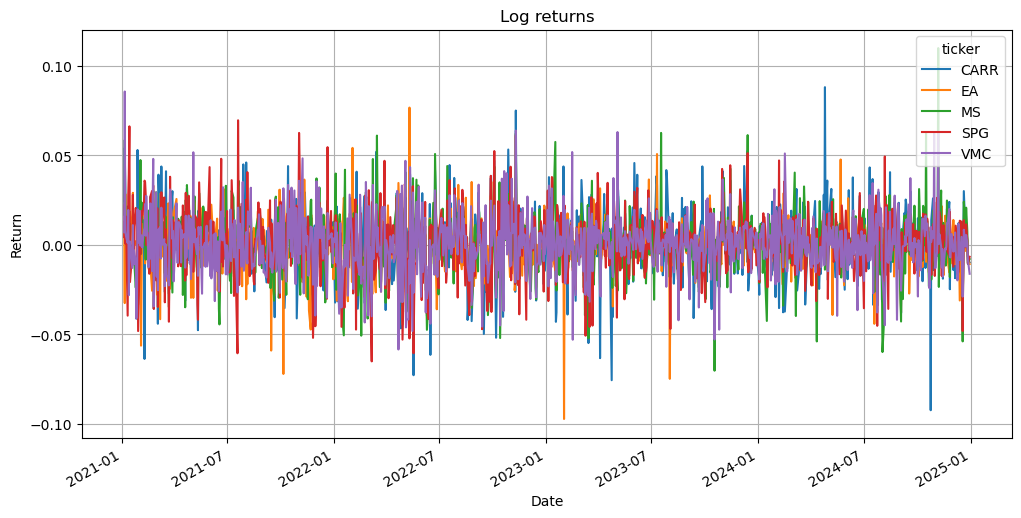

In [246]:
plot_data.plot(figsize=(12,6))
plt.title("Log returns")
plt.ylabel("Return")
plt.xlabel("Date")
plt.grid(True)
plt.show()

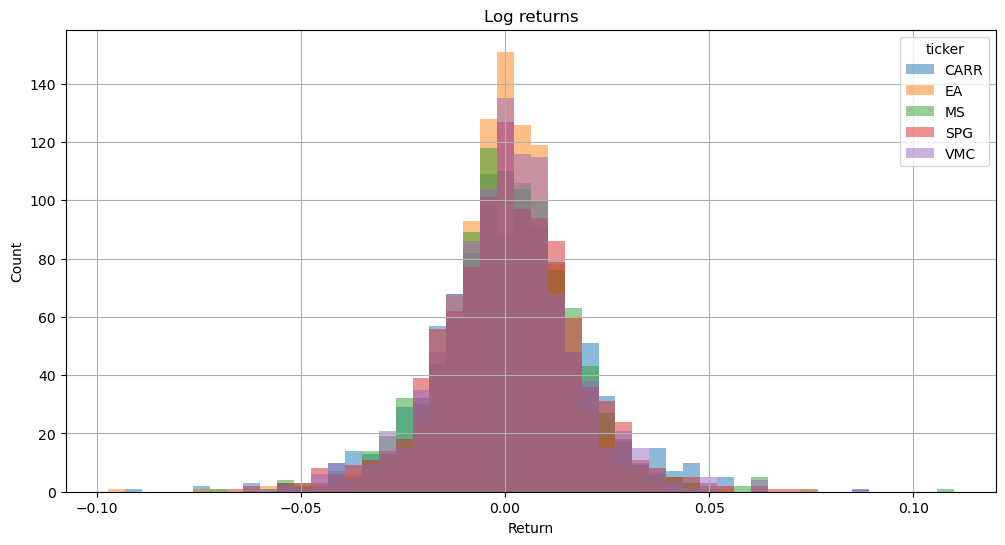

In [247]:
plot_data.plot.hist(figsize=(12,6), alpha=0.5, bins=50)
plt.title("Log returns")
plt.xlabel("Return")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [248]:
p2 =  pd.read_csv('companies_no_subindustry.csv')
p2

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [249]:
p2["included"].isna().sum()

np.int64(45)

In [250]:
p2c = p2[p2["included"].notna()].copy()
p2c

,Symbol,Security,GICS_Sector,hq,included,Founded
0,MMM,3M,Industrials,"Saint Paul, Minnesota",09.08.1976,1902
1,AOS,A. O. Smith,Industrials,"Milwaukee, Wisconsin",26.07.2017,1916
2,ABT,Abbott,Health Care,"North Chicago, Illinois",31.03.1964,1888
3,ABBV,AbbVie,Health Care,"North Chicago, Illinois",31.12.2012,2013 (1888)
4,ABMD,Abiomed,Health Care,"Danvers, Massachusetts",31.05.2018,1981
...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,"Louisville, Kentucky",06.10.1997,1997
499,ZBRA,Zebra Technologies,Information Technology,"Lincolnshire, Illinois",23.12.2019,1969
500,ZBH,Zimmer Biomet,Health Care,"Warsaw, Indiana",07.08.2001,1927
501,ZION,Zions Bancorporation,Financials,"Salt Lake City, Utah",22.06.2001,1873


In [251]:
p2c["included"] = pd.to_datetime(p2c["included"], dayfirst=True, errors="coerce")
young = p2c["included"].idxmax()
p2c.iloc[young]


Symbol                            ANET
Security               Arista Networks
GICS_Sector     Information Technology
hq             Santa Clara, California
included           2018-08-28 00:00:00
Founded                           2004
Name: 49, dtype: object

In [252]:
old = p2c["included"].idxmin()
p2c.iloc[old]


Symbol                          MO
Security                    Altria
GICS_Sector       Consumer Staples
hq              Richmond, Virginia
included       1957-03-04 00:00:00
Founded                       1985
Name: 25, dtype: object

In [253]:
median = p2c["included"].median()
from datetime import datetime, date
today = date.today()
median = datetime.date(median)

age = today.year - median.year - ((today.month, today.day) < (median.month, median.day))
age

17

<Axes: ylabel='Security'>

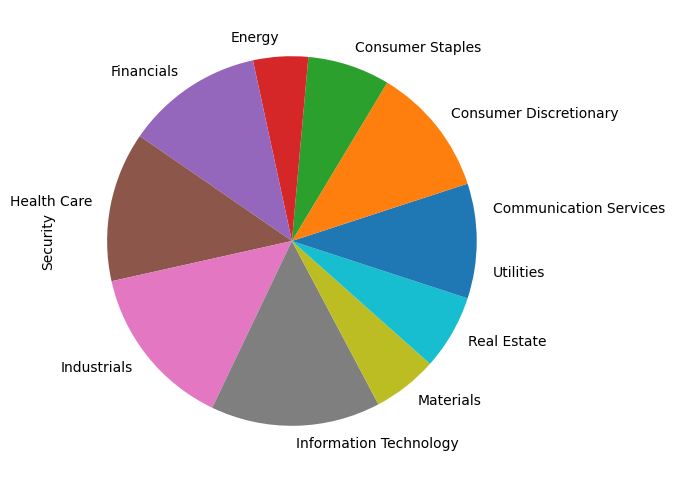

In [254]:
count = p2c.groupby("GICS_Sector")["Security"].count()
count.plot.pie(figsize=(12,6))



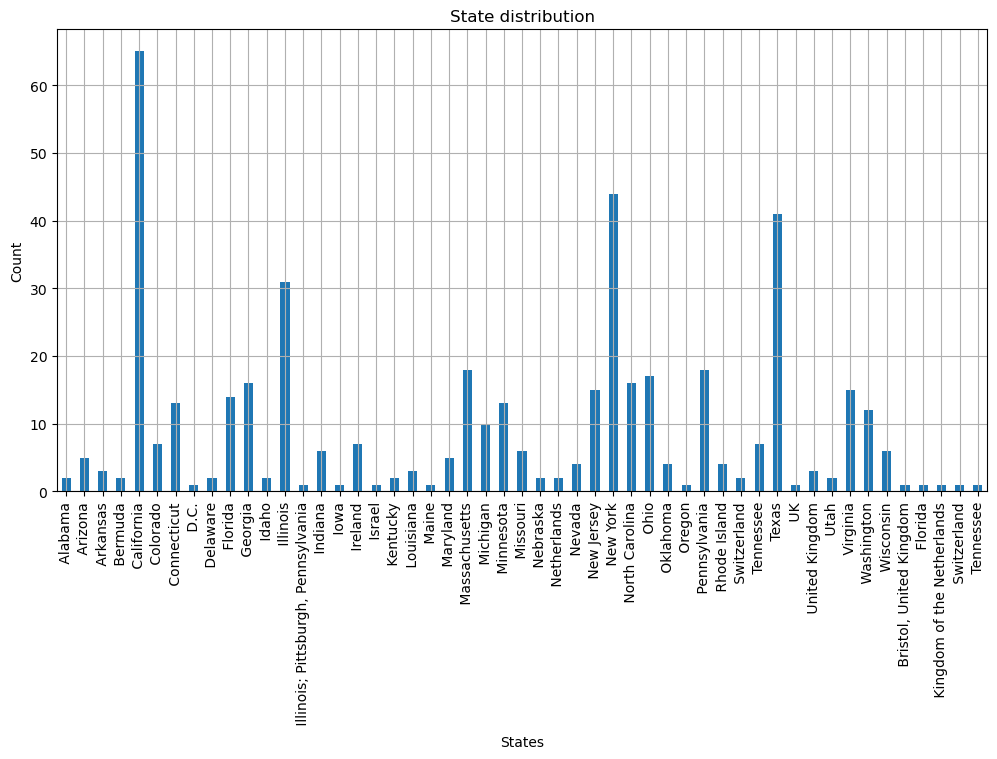

In [259]:
p2c[["City", "State"]] = p2c['hq'].str.split(",", n=1, expand = True)
state_count = p2c.groupby("State")["Security"].count()
state_count.plot.bar(figsize=(12,6))
plt.title("State distribution")
plt.xlabel("States")
plt.ylabel("Count")
plt.grid(True)
plt.show()

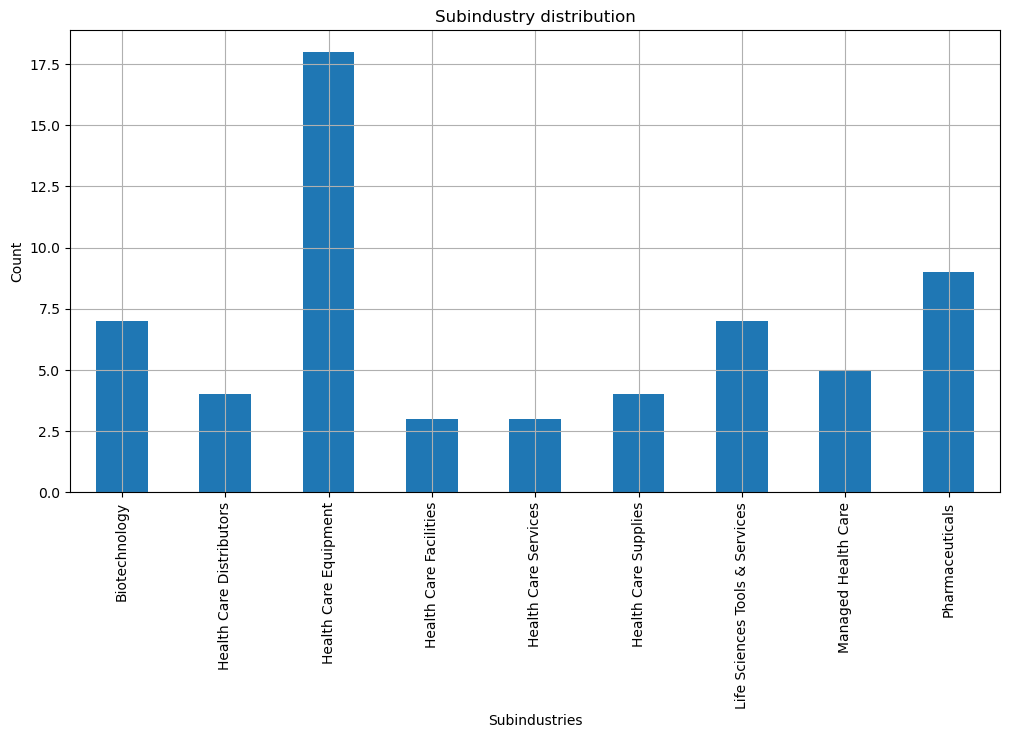

In [272]:
p27 =  pd.read_csv('companies_subindustry.csv')
new = p2c.merge(p27, how="inner", on="Symbol")
n_gics = new[new["GICS_Sector"]=="Health Care"].groupby("subindustry")["Security"].count()
n_gics.plot.bar(figsize=(12,6))
plt.title("Subindustry distribution")
plt.xlabel("Subindustries")
plt.ylabel("Count")
plt.grid(True)
plt.show()

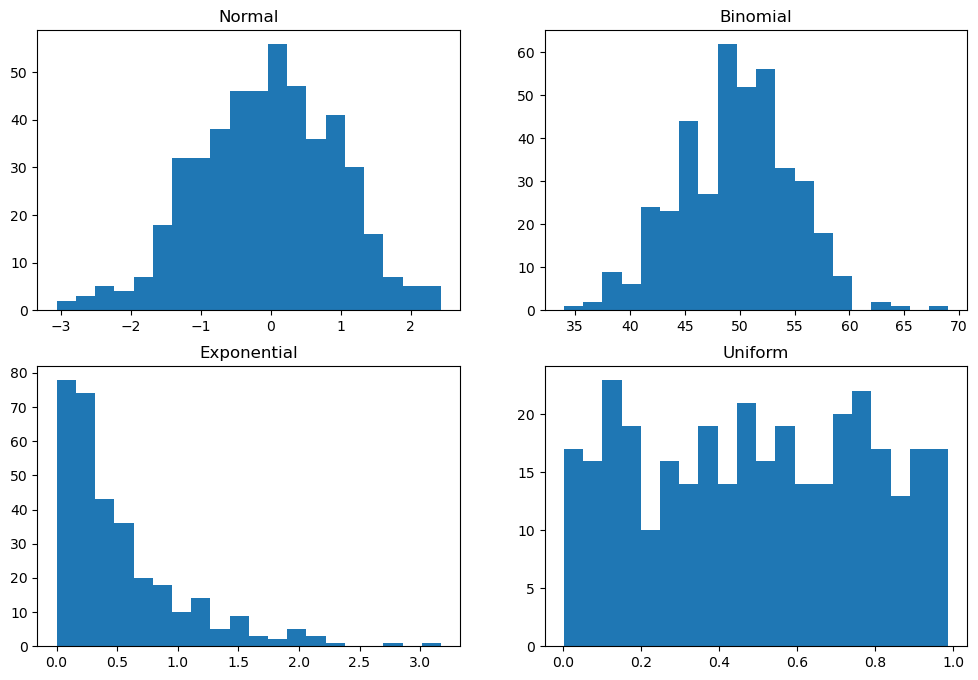

In [289]:
n_obs = np.random.randint(100,501)
u_obs = np.random.randint(100,501)
exp_obs = np.random.randint(100,501)
bin_obs = np.random.randint(100,501)
v1 = np.random.normal(0,1, n_obs)
v2 = np.random.binomial(100,0.5,bin_obs)
v3 = np.random.exponential(0.5, exp_obs)
v4 = np.random.uniform(0,1, u_obs)

fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0,0].hist(v1, bins = 20); ax[0,0].set_title("Normal")
ax[0,1].hist(v2, bins = 20); ax[0,1].set_title("Binomial")
ax[1,0].hist(v3, bins = 20); ax[1,0].set_title("Exponential")
ax[1,1].hist(v4, bins = 20); ax[1,1].set_title("Uniform")

plt.show()